In [2]:
# imports
from scipy.io import arff
import pandas as pd
import numpy as np
import random
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# !pip3 install shap xgboost scikit-learn scipy pandas numpy matplotlib seaborn imbalanced-learn

In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

In [4]:
data, meta = arff.loadarff('data/dataset.arff')
df = pd.DataFrame(data)

# Convert byte strings to integers so the encoded values stay numeric
df = df.map(lambda x: int(x.decode('utf-8')) if isinstance(x, bytes) else x)
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [5]:
print(f"Shape: {df.shape}")  # (11055, 31)
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Class distribution:\n{df['Result'].value_counts()}")
print(df.info())
print(df.describe())

Shape: (11055, 31)
Missing values: 0
Class distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  i

In [6]:
# Encoding reference for the phishing indicators:
# -1 = negative / suspicious / phishing signal
#  0 = neutral / uncertain / mixed signal
#  1 = positive / legitimate signal
#
# For the target label in Result:
# -1 = phishing
#  1 = legitimate

In [7]:
# Separate features and target before clustering or scaling
X = df.drop(columns=['Result'])
y = df['Result']

# no duplicate indices
assert len(set(X.index)) == len(X) 
# Stratified 80/20 split keeps the label distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train label distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('Test label distribution:')
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (8844, 30)
Test shape: (2211, 30)
Train label distribution:
Result
-1    0.443012
 1    0.556988
Name: proportion, dtype: float64
Test label distribution:
Result
-1    0.443238
 1    0.556762
Name: proportion, dtype: float64


In [8]:
assert len(set(X_train.index) & set(X_test.index)) == 0, "Data leakage detected!"
print("No data leakage detected")

No data leakage detected


In [9]:
# Scale the feature matrix for K-Means and keep the label separate
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# clustering-ready inputs; y stays separate for evaluation
X_train_kmeans = X_train_scaled.copy()
X_test_kmeans = X_test_scaled.copy()

print('Scaled train shape:', X_train_kmeans.shape)
print('Scaled test shape:', X_test_kmeans.shape)

Scaled train shape: (8844, 30)
Scaled test shape: (2211, 30)


### EDA

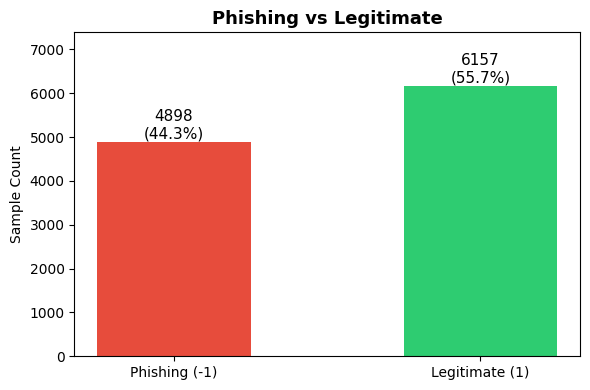

In [10]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(
    ['Phishing (-1)', 'Legitimate (1)'],
    counts.values,
    color=['#e74c3c', '#2ecc71'],
    width=0.5
)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{count}\n({count/len(y)*100:.1f}%)',
            ha='center', fontsize=11)
ax.set_title('Phishing vs Legitimate', fontsize=13, fontweight='bold')
ax.set_ylabel('Sample Count')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()

In [11]:
# feature groups 
feature_groups = {
    'URL-Based': [
        'having_IP_Address', 'URL_Length', 'Shortining_Service',
        'having_At_Symbol', 'double_slash_redirecting',
        'Prefix_Suffix', 'having_Sub_Domain', 'HTTPS_token'
    ],
    'Domain-Based': [
        'SSLfinal_State', 'Domain_registeration_length',
        'Favicon', 'port', 'age_of_domain', 'DNSRecord'
    ],
    'HTML/JS-Based': [
        'Request_URL', 'URL_of_Anchor', 'Links_in_tags',
        'SFH', 'Submitting_to_email', 'Abnormal_URL',
        'Redirect', 'on_mouseover', 'RightClick',
        'popUpWidnow', 'Iframe'
    ],
    'External Services': [
        'web_traffic', 'Page_Rank', 'Google_Index',
        'Links_pointing_to_page', 'Statistical_report'
    ]
}

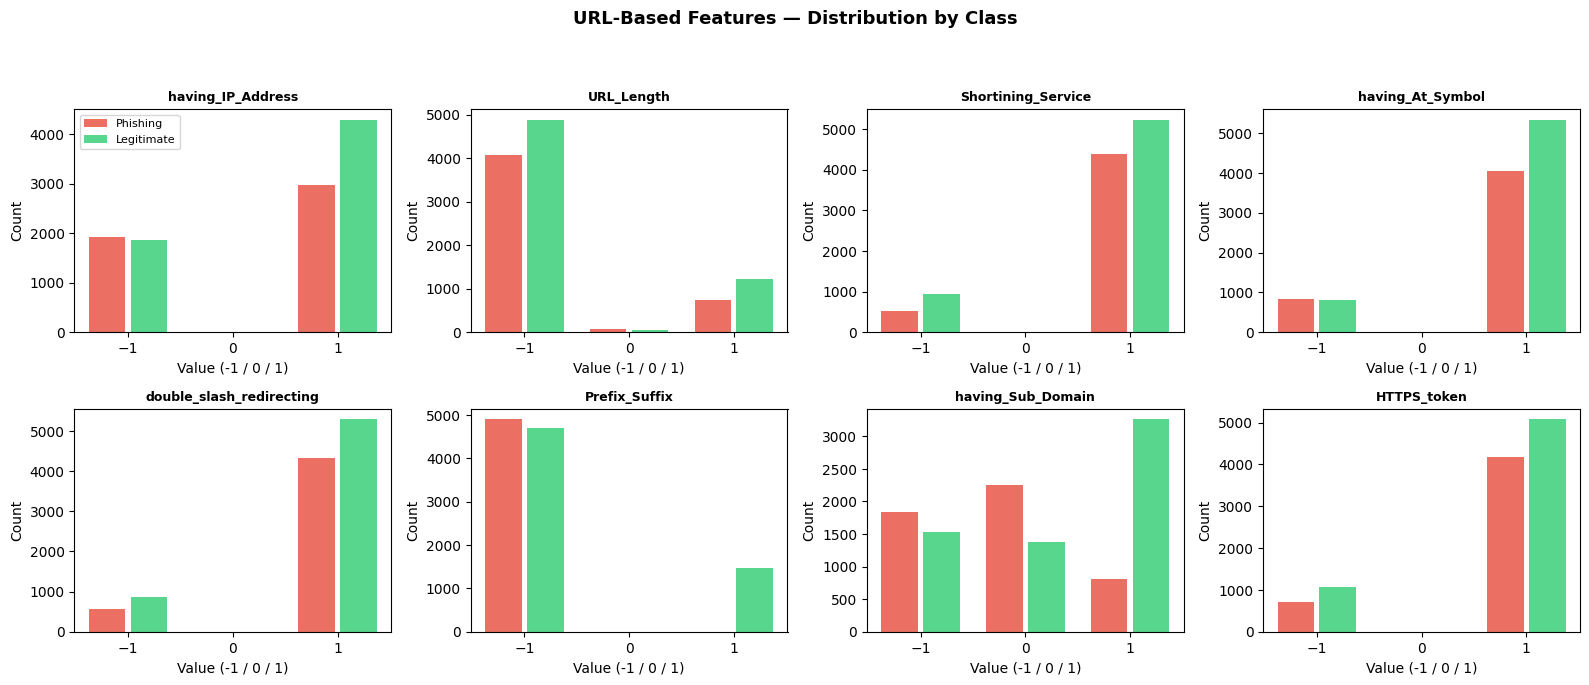

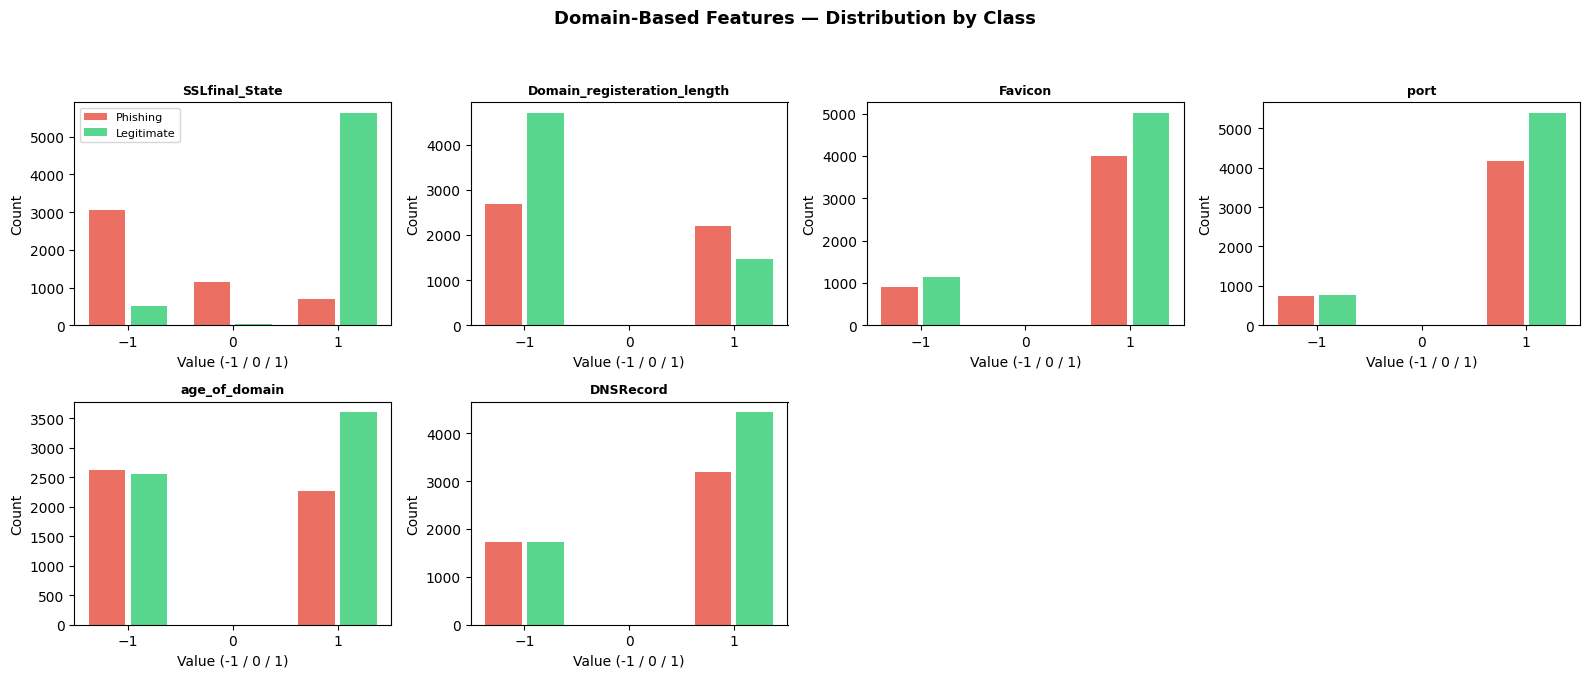

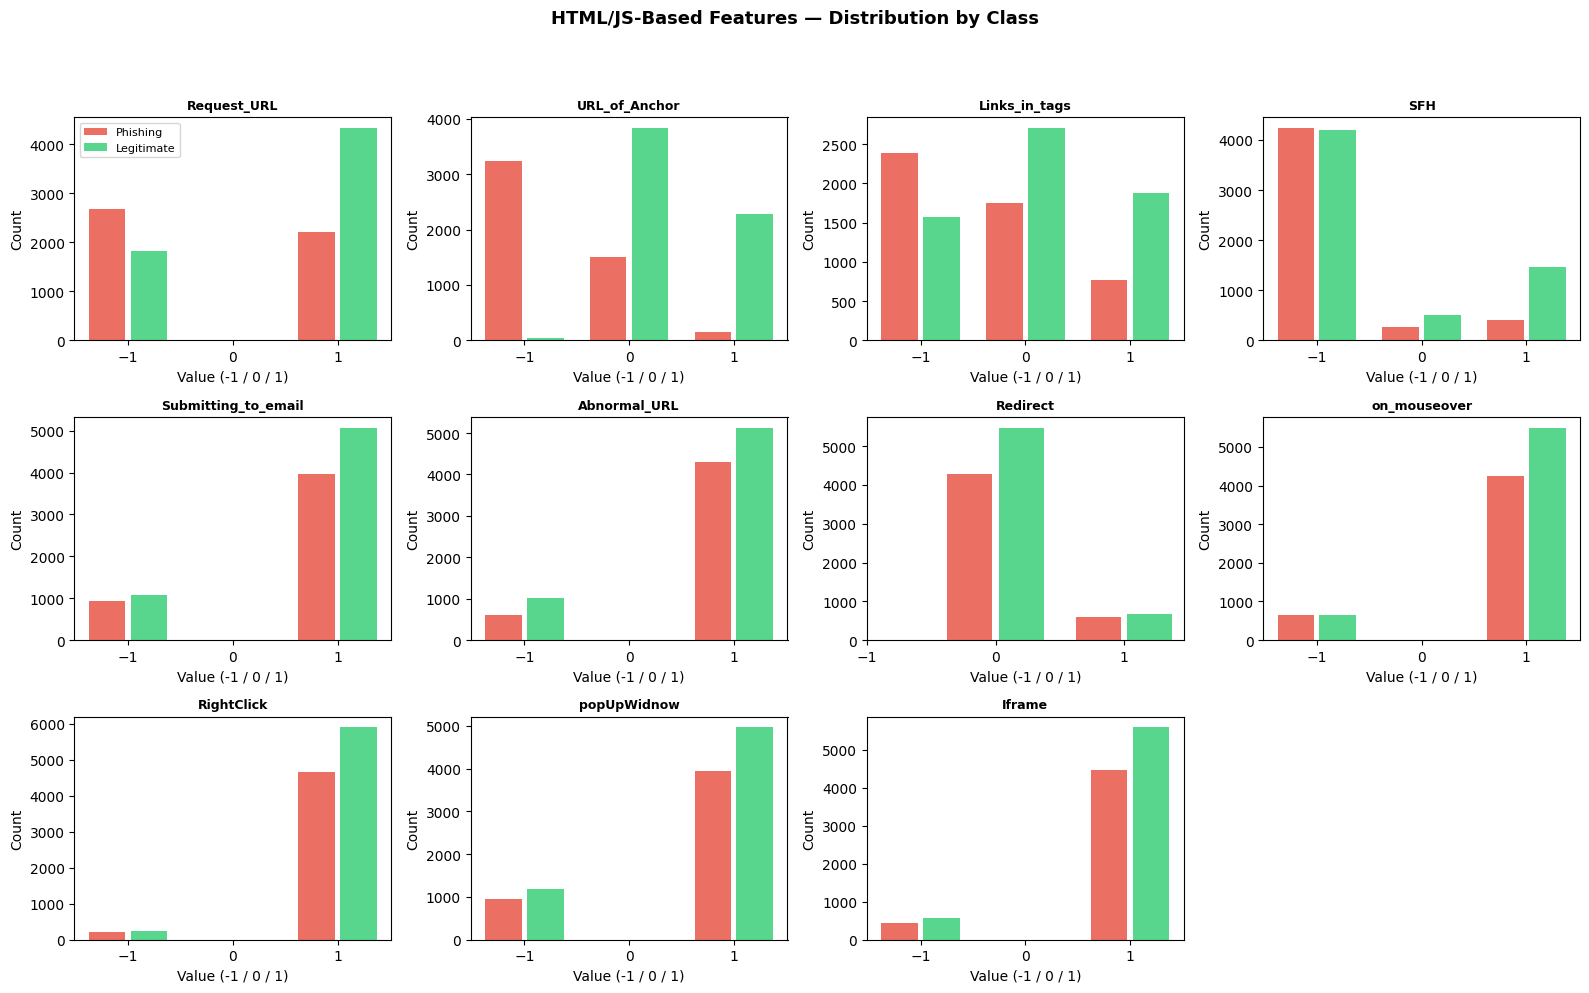

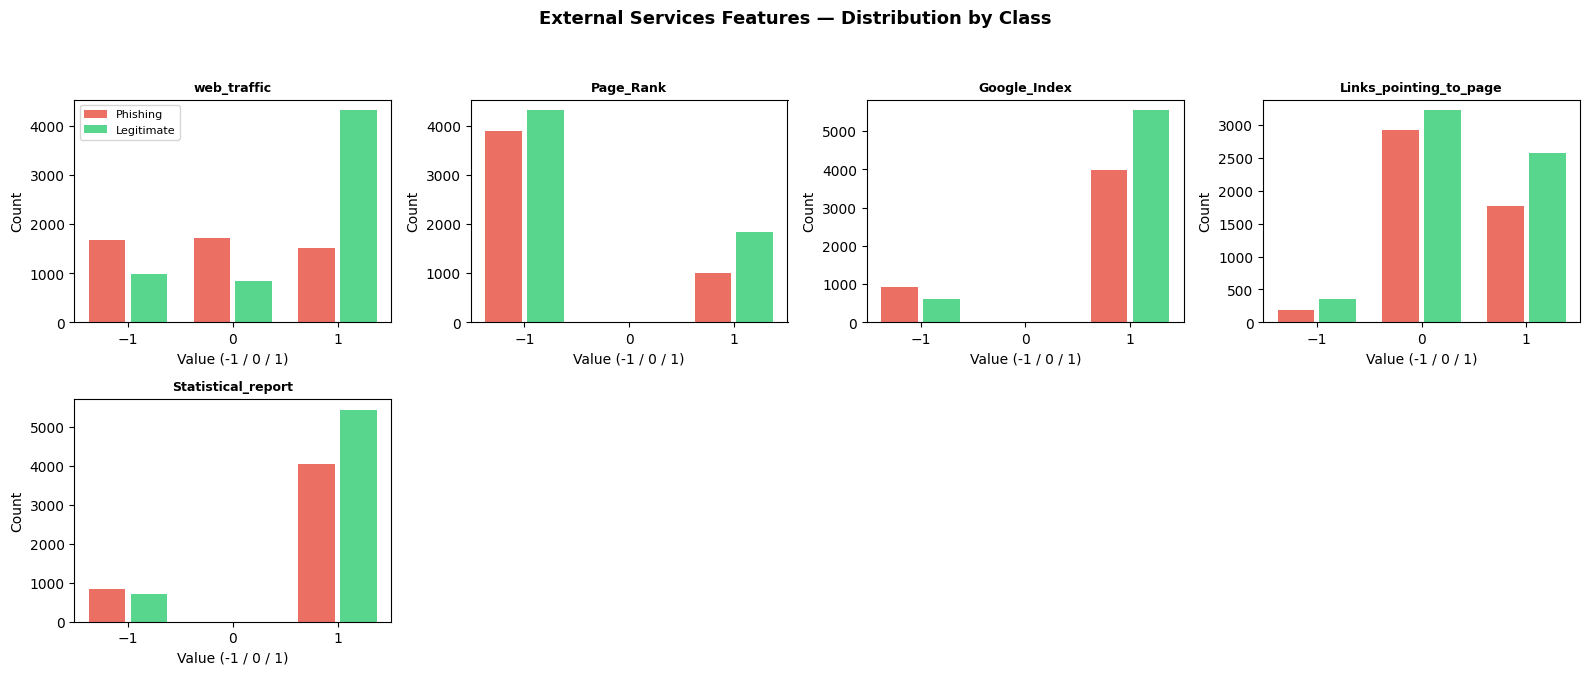

In [12]:
# Feature Value Distribution by Class
df_plot = X.copy()
df_plot['Result'] = y.values

for group_name, features in feature_groups.items():
    n = len(features)
    ncols = 4
    nrows = (n + ncols - 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        for label, color, name in [(-1, '#e74c3c', 'Phishing'), (1, '#2ecc71', 'Legitimate')]:
            subset = df_plot[df_plot['Result'] == label][feat]
            counts_feat = subset.value_counts().sort_index()
            ax.bar(
                [x + (0.2 if label == 1 else -0.2) for x in counts_feat.index],
                counts_feat.values,
                width=0.35,
                color=color,
                alpha=0.8,
                label=name
            )
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xticks([-1, 0, 1])
        ax.set_xlabel('Value (-1 / 0 / 1)')
        ax.set_ylabel('Count')
        if i == 0:
            ax.legend(fontsize=8)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{group_name} Features — Distribution by Class',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'figures/eda_{group_name.lower().replace("/", "_").replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

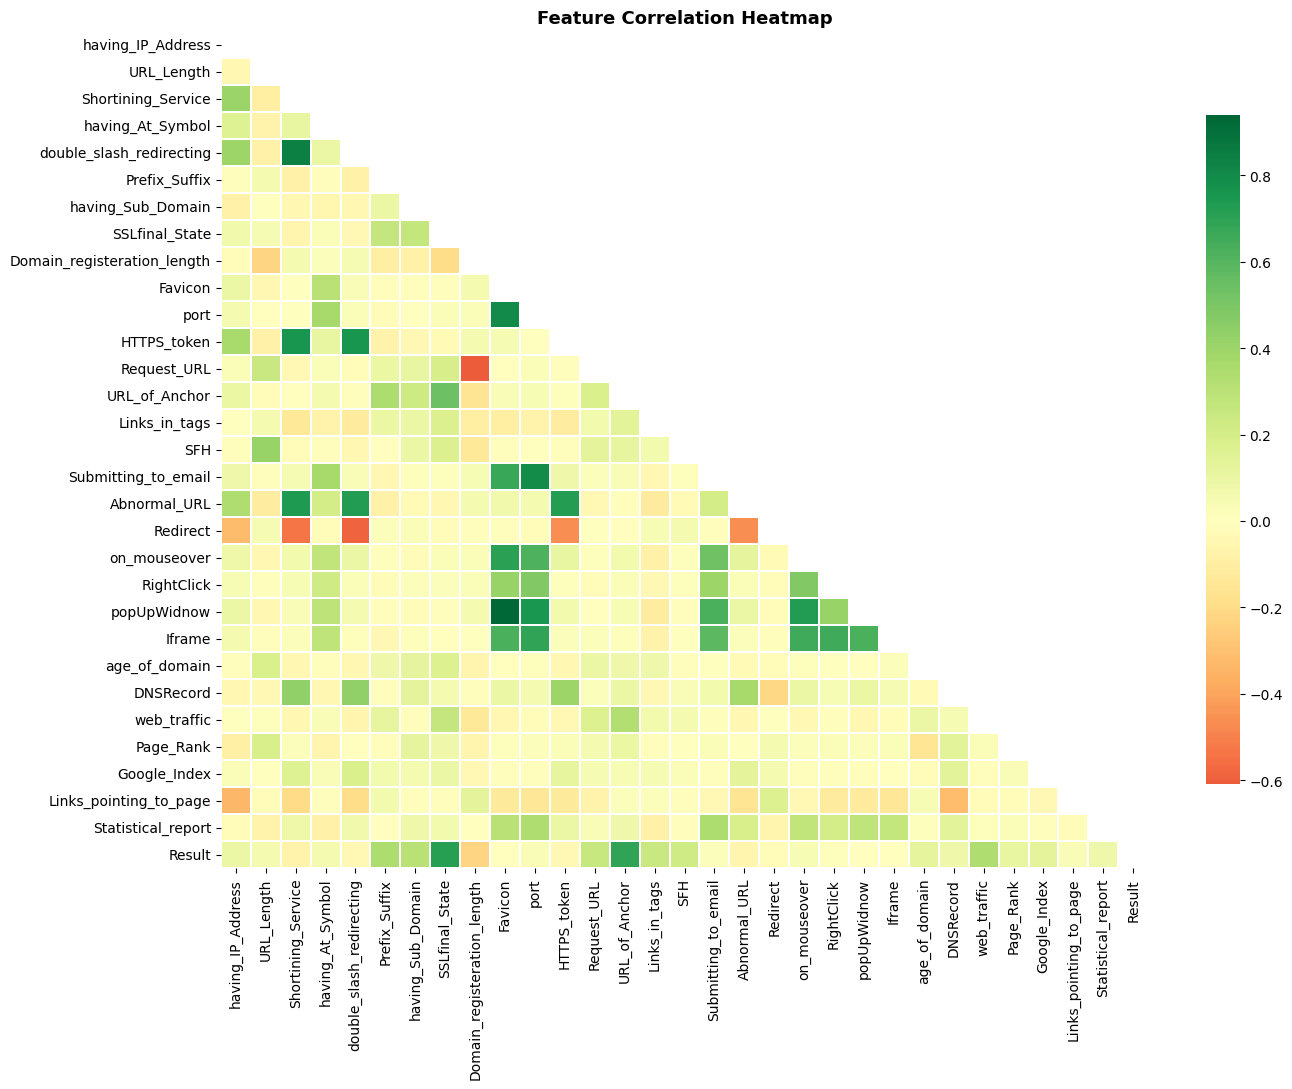

In [13]:
#  Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='RdYlGn',
    center=0, linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150)
plt.show()

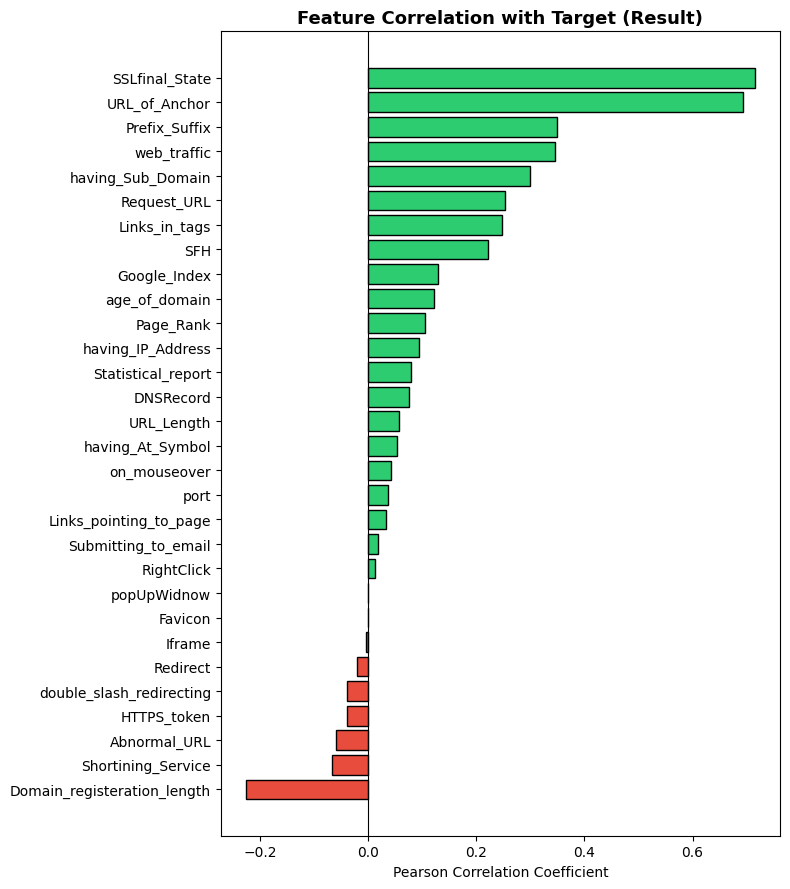

In [14]:
# Correlation with Target 
target_corr = df.corr()['Result'].drop('Result').sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Result)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('figures/target_correlation.png', dpi=150)
plt.show()

In [15]:
# 6. Summary 
print("EDA SUMMARY: ")
print(f"Dataset size: {df.shape[0]} samples, {df.shape[1]-1} features")
print(f"Class balance: {counts.values[0]} phishing ({counts.values[0]/len(y)*100:.1f}%), "
      f"{counts.values[1]} legitimate ({counts.values[1]/len(y)*100:.1f}%)")
print("\nTop 5 features most correlated with being PHISHING (negative):")
print(target_corr.head(5).to_string())
print("\nTop 5 features most correlated with being LEGITIMATE (positive):")
print(target_corr.tail(5).to_string())

EDA SUMMARY: 
Dataset size: 11055 samples, 30 features
Class balance: 4898 phishing (44.3%), 6157 legitimate (55.7%)

Top 5 features most correlated with being PHISHING (negative):
Domain_registeration_length   -0.225789
Shortining_Service            -0.067966
Abnormal_URL                  -0.060488
HTTPS_token                   -0.039854
double_slash_redirecting      -0.038608

Top 5 features most correlated with being LEGITIMATE (positive):
having_Sub_Domain    0.298323
web_traffic          0.346103
Prefix_Suffix        0.348606
URL_of_Anchor        0.692935
SSLfinal_State       0.714741


### K-Means Clustering

k=2 | Inertia: 225452 | Silhouette: 0.2810
k=3 | Inertia: 197045 | Silhouette: 0.2863
k=4 | Inertia: 183495 | Silhouette: 0.1131
k=5 | Inertia: 177232 | Silhouette: 0.1067
k=6 | Inertia: 169527 | Silhouette: 0.1108
k=7 | Inertia: 164800 | Silhouette: 0.1148
k=8 | Inertia: 161586 | Silhouette: 0.1124
k=9 | Inertia: 158112 | Silhouette: 0.1035
k=10 | Inertia: 154246 | Silhouette: 0.0863


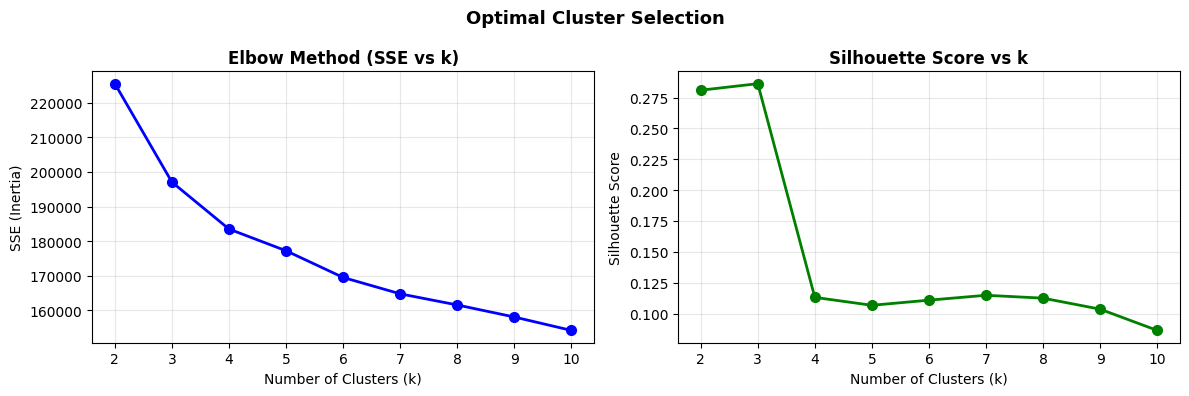

In [16]:
# Elbow Method and Silhouette Scores
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_train_kmeans)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_kmeans, labels))
    print(f"k={k} | Inertia: {km.inertia_:.0f} | Silhouette: {silhouette_score(X_train_kmeans, labels):.4f}")

# side by side metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (SSE vs k)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('SSE (Inertia)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/kmeans_selection.png', dpi=150)
plt.show()

In [17]:
#  Final K-Means adjusted based on silhouette scores
OPTIMAL_K = k_range[np.argmax(silhouette_scores)] # Choose k with highest silhouette score
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
train_clusters = km_final.fit_predict(X_train_kmeans)
test_clusters  = km_final.predict(X_test_kmeans)

print(f"\nChosen k = {OPTIMAL_K}")
print("Cluster sizes (train):")
for c in range(OPTIMAL_K):
    print(f"  Cluster {c}: {(train_clusters == c).sum()} samples")


Chosen k = 3
Cluster sizes (train):
  Cluster 0: 6656 samples
  Cluster 1: 1238 samples
  Cluster 2: 950 samples



PCA explained variance: [0.17975282 0.13551062]
Total variance explained: 31.5%


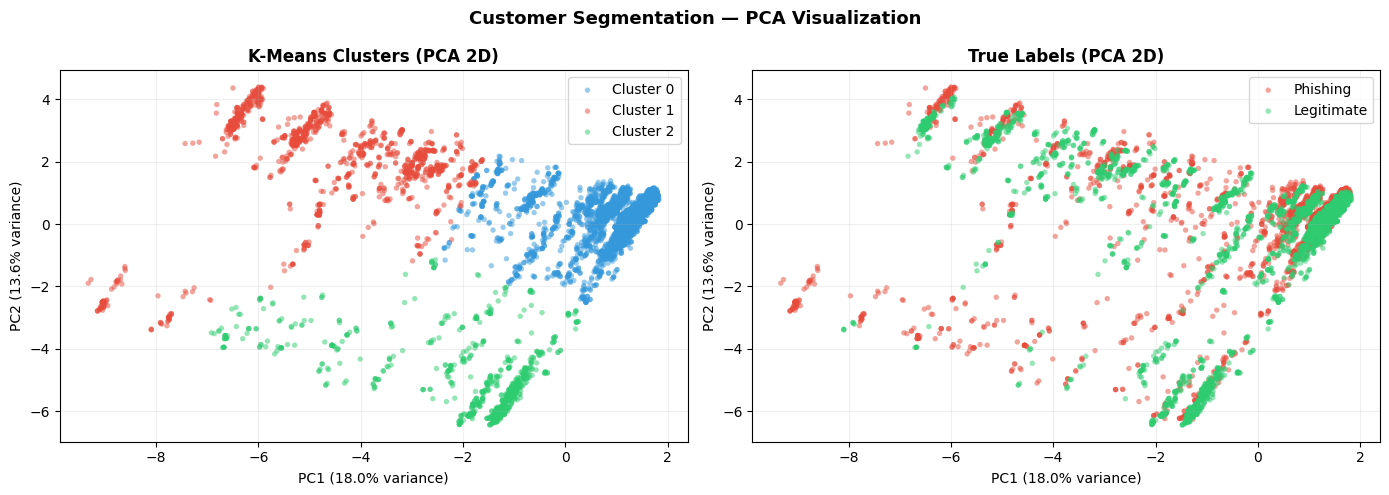

In [18]:
# PCA Visualization 
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_kmeans)

print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
label_colors = {-1: '#e74c3c', 1: '#2ecc71'}
label_names  = {-1: 'Phishing', 1: 'Legitimate'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by K-Means cluster
for c in range(OPTIMAL_K):
    mask = train_clusters == c
    axes[0].scatter(
        X_train_pca[mask, 0], X_train_pca[mask, 1],
        c=cluster_colors[c], label=f'Cluster {c}',
        alpha=0.5, s=15, edgecolors='none'
    )
axes[0].set_title('K-Means Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Right: colored by true label (phishing vs legitimate)
for label in [-1, 1]:
    mask = y_train.values == label
    axes[1].scatter(
        X_train_pca[mask, 0], X_train_pca[mask, 1],
        c=label_colors[label], label=label_names[label],
        alpha=0.5, s=15, edgecolors='none'
    )
axes[1].set_title('True Labels (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.suptitle('Customer Segmentation — PCA Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/pca_clusters.png', dpi=150)
plt.show()


In [19]:
# Cluster Profile Analysis 
cluster_df = X_train.copy()
cluster_df['Cluster'] = train_clusters
cluster_df['Result'] = y_train.values

print("\n CLUSTER PROFILE: ")
print("Phishing rate per cluster:")
for c in range(OPTIMAL_K):
    subset = cluster_df[cluster_df['Cluster'] == c]
    phishing_rate = (subset['Result'] == -1).sum() / len(subset)
    size = len(subset)
    print(f"  Cluster {c}: {size} samples | {phishing_rate*100:.1f}% phishing")

# Mean feature values per cluster
cluster_means = cluster_df.groupby('Cluster')[X_train.columns.tolist()].mean()
print("\nMean feature values per cluster:")
print(cluster_means.T.to_string())


 CLUSTER PROFILE: 
Phishing rate per cluster:
  Cluster 0: 6656 samples | 46.0% phishing
  Cluster 1: 1238 samples | 44.3% phishing
  Cluster 2: 950 samples | 32.7% phishing

Mean feature values per cluster:
Cluster                             0         1         2
having_IP_Address            0.493690  0.198708 -0.757895
URL_Length                  -0.666767 -0.596123 -0.453684
Shortining_Service           0.964243  0.831987 -0.936842
having_At_Symbol             0.834435  0.077544  0.572632
double_slash_redirecting     0.969050  0.812601 -0.930526
Prefix_Suffix               -0.769531 -0.686591 -0.555789
having_Sub_Domain            0.054688  0.062197  0.191579
SSLfinal_State               0.212891  0.264943  0.466316
Domain_registeration_length -0.294471 -0.423263 -0.524211
Favicon                      0.914663 -0.962843  0.709474
port                         0.994291 -0.809370  0.867368
HTTPS_token                  0.899339  0.733441 -0.938947
Request_URL                  0.170673

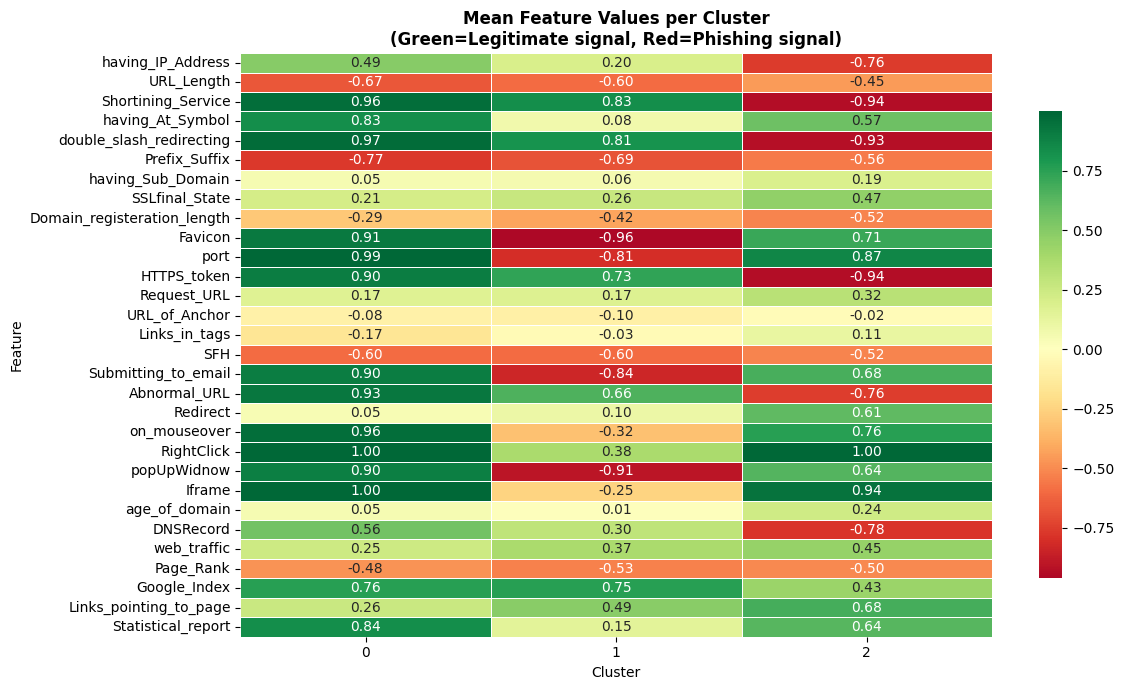

In [20]:
# Cluster heatmap
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    cluster_means.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Mean Feature Values per Cluster\n(Green=Legitimate signal, Red=Phishing signal)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('figures/cluster_heatmap.png', dpi=150)
plt.show()

In [24]:
from sklearn.cluster import DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0, 3.0]
min_samples_values = [5, 10]

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_train_kmeans)

        unique, counts = np.unique(labels, return_counts=True)
        cluster_info = dict(zip(unique, counts))

        noise_pct = cluster_info.get(-1, 0) / len(labels) * 100
        num_clusters = len([k for k in unique if k != -1])

        print(f"eps={eps}, min_samples={ms}")
        print(f"  clusters: {num_clusters}")
        print(f"  noise %: {noise_pct:.1f}%")
        print("-" * 40)

eps=0.5, min_samples=5
  clusters: 178
  noise %: 86.4%
----------------------------------------
eps=0.5, min_samples=10
  clusters: 17
  noise %: 97.5%
----------------------------------------
eps=1.0, min_samples=5
  clusters: 178
  noise %: 86.4%
----------------------------------------
eps=1.0, min_samples=10
  clusters: 17
  noise %: 97.5%
----------------------------------------
eps=1.5, min_samples=5
  clusters: 213
  noise %: 63.7%
----------------------------------------
eps=1.5, min_samples=10
  clusters: 67
  noise %: 78.7%
----------------------------------------
eps=2.0, min_samples=5
  clusters: 226
  noise %: 51.2%
----------------------------------------
eps=2.0, min_samples=10
  clusters: 78
  noise %: 65.1%
----------------------------------------
eps=3.0, min_samples=5
  clusters: 101
  noise %: 21.0%
----------------------------------------
eps=3.0, min_samples=10
  clusters: 23
  noise %: 30.9%
----------------------------------------


In [25]:
dbscan = DBSCAN(eps=3.0, min_samples=10)

dbscan_labels_train = dbscan.fit_predict(X_train_kmeans)
dbscan_labels_test = dbscan.fit_predict(X_test_kmeans)

In [27]:
print(dbscan_labels_train[:20])

unique, counts = np.unique(dbscan_labels_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")
    df_dbscan = pd.DataFrame({
    'cluster_dbscan': dbscan_labels_train
})

print(df_dbscan.head())

debug_df = X_train.copy()
debug_df['cluster_dbscan'] = dbscan_labels_train
debug_df['Result'] = y_train.values

print(debug_df.head())

debug_df.groupby('cluster_dbscan')['Result'].value_counts(normalize=True)

[ 0 -1  0  0 -1 -1 -1  0  0  0  0 -1  0  0  0 -1  0  0  0 -1]
Cluster -1: 2737
Cluster 0: 5249
Cluster 1: 167
Cluster 2: 296
Cluster 3: 11
Cluster 4: 77
Cluster 5: 12
Cluster 6: 22
Cluster 7: 37
Cluster 8: 35
Cluster 9: 22
Cluster 10: 12
Cluster 11: 35
Cluster 12: 22
Cluster 13: 14
Cluster 14: 11
Cluster 15: 11
Cluster 16: 10
Cluster 17: 10
Cluster 18: 10
Cluster 19: 11
Cluster 20: 11
Cluster 21: 13
Cluster 22: 9
   cluster_dbscan
0               0
1              -1
2               0
3               0
4              -1
       having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
1758                   1          -1                   1                 1   
10910                  1          -1                   1                 1   
7412                   1          -1                   1                 1   
5805                   1          -1                   1                 1   
9259                   1           1                  -1                -1   

      

cluster_dbscan  Result
-1               1        0.550603
                -1        0.449397
 0               1        0.544675
                -1        0.455325
 1              -1        0.718563
                 1        0.281437
 2               1        0.844595
                -1        0.155405
 3               1        0.727273
                -1        0.272727
 4               1        0.987013
                -1        0.012987
 5               1        1.000000
 6               1        0.636364
                -1        0.363636
 7              -1        1.000000
 8               1        0.742857
                -1        0.257143
 9               1        0.909091
                -1        0.090909
 10              1        1.000000
 11              1        0.885714
                -1        0.114286
 12             -1        0.863636
                 1        0.136364
 13              1        1.000000
 14              1        1.000000
 15             -1        1.0000

In [28]:
cluster_summary = (
    debug_df.groupby('cluster_dbscan')['Result']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Create mapping
cluster_map = {}

for cluster in cluster_summary.index:
    if cluster == -1:
        cluster_map[cluster] = 'noise'
    else:
        phishing_ratio = cluster_summary.loc[cluster, -1] if -1 in cluster_summary.columns else 0
        
        if phishing_ratio > 0.6:
            cluster_map[cluster] = 'phishing_cluster'
        else:
            cluster_map[cluster] = 'legit_cluster'

# Apply mapping
debug_df['dbscan_group'] = debug_df['cluster_dbscan'].map(cluster_map)

print(debug_df[['cluster_dbscan', 'dbscan_group']].head())

debug_df['dbscan_group'].value_counts(normalize=True)

       cluster_dbscan   dbscan_group
1758                0  legit_cluster
10910              -1          noise
7412                0  legit_cluster
5805                0  legit_cluster
9259               -1          noise


dbscan_group
legit_cluster       0.659204
noise               0.309475
phishing_cluster    0.031321
Name: proportion, dtype: float64

In [29]:
print("KMeans train:", train_clusters.shape)
print("KMeans test:", test_clusters.shape)

print("DBSCAN train:", dbscan_labels_train.shape)
print("DBSCAN test:", dbscan_labels_test.shape)

print("\nSample KMeans:", train_clusters[:10])
print("Sample DBSCAN:", dbscan_labels_train[:10])

KMeans train: (8844,)
KMeans test: (2211,)
DBSCAN train: (8844,)
DBSCAN test: (2211,)

Sample KMeans: [0 0 0 0 2 2 2 0 0 0]
Sample DBSCAN: [ 0 -1  0  0 -1 -1 -1  0  0  0]


In [30]:
# Save processed data
X_train_scaled.to_csv('data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test_scaled.csv', index=False)
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False, header=['label'])
y_test.to_csv('data/processed/y_test.csv', index=False, header=['label'])

# Save KMeans clusters (rename these)
np.save('data/processed/kmeans_train.npy', train_clusters)
np.save('data/processed/kmeans_test.npy', test_clusters)

# Save DBSCAN clusters (ADD THIS)
np.save('data/processed/dbscan_train.npy', dbscan_labels_train)
np.save('data/processed/dbscan_test.npy', dbscan_labels_test)

# Save models
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)

with open('models/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)